<a href="https://colab.research.google.com/github/ilaydatosun-de/uav-telemetry-analytics/blob/main/UAV_Swarm_Telemetry_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

           PRODUCT ASSURANCE & QUALITY REPORT         
Total Telemetry Frames Audited : 1000
Detected Critical Fault Events : 6
Operational Fleet Reliability  : 99.40%


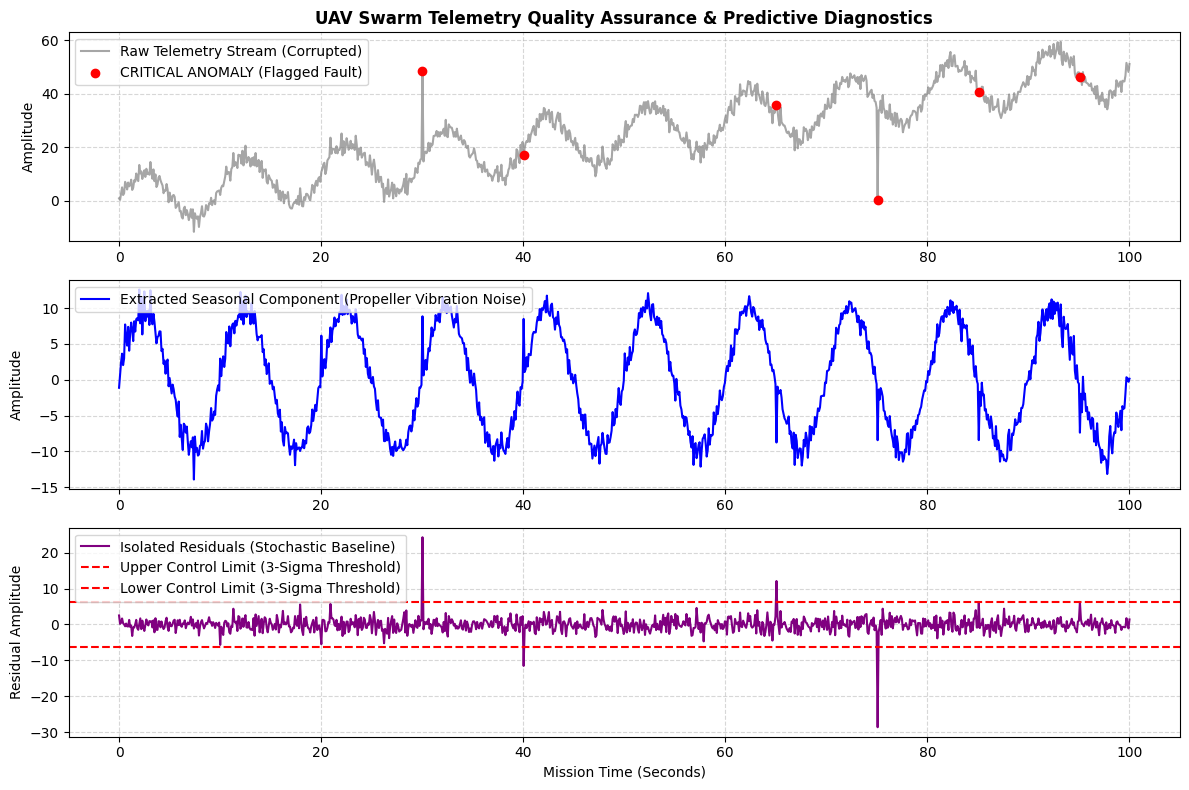

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# =============================================================================
# 1. TELEMETRY DATA SIMULATION
# =============================================================================
# Simulating a continuous telemetry stream from a UAV swarm operating under deterministic environmental dynamics and high-frequency structural noise.
np.random.seed(42)
time = np.linspace(0, 100, 1000)

# Decomposing the synthetic stream into underlying physical components:
# - Linear Trend: Core flight trajectory/sensor drift
# - Seasonal Component: Periodic deterministic noise (e.g., propeller/motor vibrations)
# - White Noise: Stochastic atmospheric disturbances (Gaussian distribution)
trend = 0.5 * time
seasonal = 10 * np.sin(2 * np.pi * time / 10)
noise = np.random.normal(0, 2, len(time))
telemetry_signal = trend + seasonal + noise

# Injecting discrete system faults / anomaly events (Simulating Jamming or Hardware Failure)
# Inducing spontaneous signal spikes at specific timestamps (t=300 and t=750)
telemetry_signal[300] += 35
telemetry_signal[750] -= 35

# Constructing the core telemetry DataFrame
df = pd.DataFrame({'Time': time, 'Signal': telemetry_signal})


# =============================================================================
# 2. SIGNAL DECOMPOSITION VIA STL
# =============================================================================
# Implementing Seasonal-Trend Decomposition using Loess (STL).
# This statistical approach robustly isolates the true carrier trend and periodic channel interference, yielding a cleaned residual space for audit and diagnostics.
res = STL(df['Signal'], period=100).fit()

df['Trend'] = res.trend
df['Seasonal'] = res.seasonal
df['Resid'] = res.resid  # Residual component isolated for statistical anomaly detection


# =============================================================================
# 3. STATISTICAL ANOMALY DETECTION
# =============================================================================
# Applying a standard industrial Quality Assurance framework (Three-Sigma Rule).
# Any statistical deviation beyond 3 standard deviations from the residual mean is flagged as a critical operational anomaly or signal breach.
threshold_upper = df['Resid'].mean() + 3 * df['Resid'].std()
threshold_lower = df['Resid'].mean() - 3 * df['Resid'].std()

# Binary flagging of statistical outliers
df['Anomaly'] = (df['Resid'] > threshold_upper) | (df['Resid'] < threshold_lower)
anomalies = df[df['Anomaly']]


# =============================================================================
# 4. QUANTITATIVE PRODUCT ASSURANCE (PA) REPORT GENERATION
# =============================================================================
# Computing high-level Key Performance Indicators (KPIs) to evaluate overall mission reliability and telecommunication link integrity.
total_data_points = len(df)
anomaly_count = len(anomalies)
system_reliability_kpi = ((total_data_points - anomaly_count) / total_data_points) * 100

print(f"======================================================")
print(f"           PRODUCT ASSURANCE & QUALITY REPORT         ")
print(f"======================================================")
print(f"Total Telemetry Frames Audited : {total_data_points}")
print(f"Detected Critical Fault Events : {anomaly_count}")
print(f"Operational Fleet Reliability  : {system_reliability_kpi:.2f}%")
print(f"======================================================")


# =============================================================================
# 5. DATA VISUALIZATION & DIAGNOSTICS
# =============================================================================
plt.figure(figsize=(12, 8))

# Subplot 1: Raw Telemetry Stream vs. Flagged System Failures
plt.subplot(3, 1, 1)
plt.plot(df['Time'], df['Signal'], label='Raw Telemetry Stream (Corrupted)', color='gray', alpha=0.7)
plt.scatter(anomalies['Time'], anomalies['Signal'], color='red', label='CRITICAL ANOMALY (Flagged Fault)', zorder=5)
plt.title('UAV Swarm Telemetry Quality Assurance & Predictive Diagnostics', fontsize=12, fontweight='bold')
plt.ylabel('Amplitude')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Isolated Deterministic Environmental/Motor Noise
plt.subplot(3, 1, 2)
plt.plot(df['Time'], df['Seasonal'], label='Extracted Seasonal Component (Propeller Vibration Noise)', color='blue')
plt.ylabel('Amplitude')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

# Subplot 3: Residual Analysis & Three-Sigma Operational Bounds
plt.subplot(3, 1, 3)
plt.plot(df['Time'], df['Resid'], label='Isolated Residuals (Stochastic Baseline)', color='purple')
plt.axhline(threshold_upper, color='r', linestyle='--', label='Upper Control Limit (3-Sigma Threshold)')
plt.axhline(threshold_lower, color='r', linestyle='--', label='Lower Control Limit (3-Sigma Threshold)')
plt.xlabel('Mission Time (Seconds)')
plt.ylabel('Residual Amplitude')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
